<a href="https://colab.research.google.com/github/Srushti070/YuvaIntern-Logistics-Data-Analyst/blob/main/Week-1/Week_1_Logistics_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
orders.shape

(99441, 8)

In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [6]:
date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [7]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [8]:
orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [9]:
orders["late_flag"] = (orders["delay_days"] > 0).astype(int)

In [10]:
completed = orders[
    orders["order_delivered_customer_date"].notna()
    & orders["order_estimated_delivery_date"].notna()
].copy()

In [11]:
on_time_rate = (completed["late_flag"] == 0).mean() * 100

print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")

On-Time Delivery Rate: 91.89%


In [12]:
avg_delivery_time = completed["delivery_days"].mean()

print(f"Average Delivery Time: {avg_delivery_time:.2f} days")

Average Delivery Time: 12.56 days


In [13]:
late_rate = completed["late_flag"].mean() * 100

print(f"Late Delivery Rate: {late_rate:.2f}%")

Late Delivery Rate: 8.11%


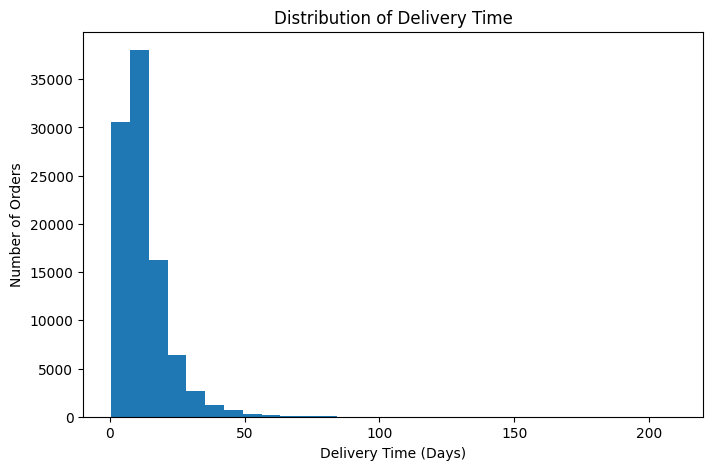

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    completed["delivery_days"].dropna(),
    bins=30
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Delivery Time")

plt.show()

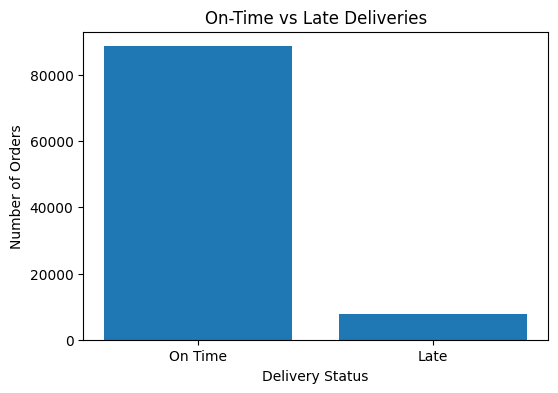

In [15]:
late_counts = completed["late_flag"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    ["On Time", "Late"],
    [
        late_counts.get(0, 0),
        late_counts.get(1, 0)
    ]
)

plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.title("On-Time vs Late Deliveries")

plt.show()

In [16]:
items = pd.read_csv("olist_order_items_dataset.csv")

items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [17]:
average_freight = items["freight_value"].mean()

print(f"Average Freight Cost: {average_freight:.2f}")

Average Freight Cost: 19.99


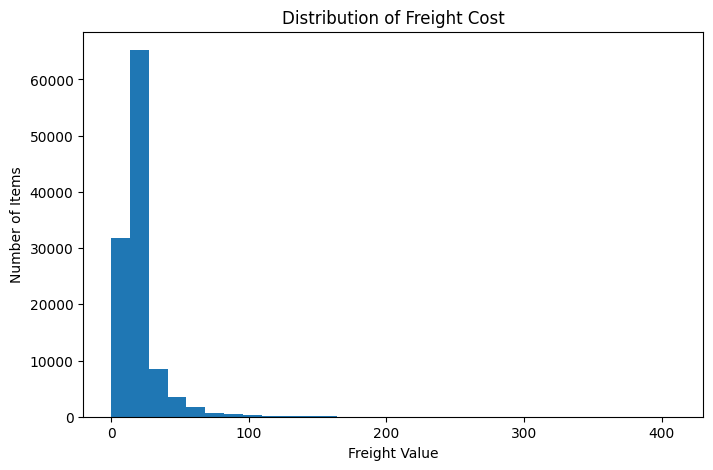

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    items["freight_value"].dropna(),
    bins=30
)

plt.xlabel("Freight Value")
plt.ylabel("Number of Items")
plt.title("Distribution of Freight Cost")

plt.show()

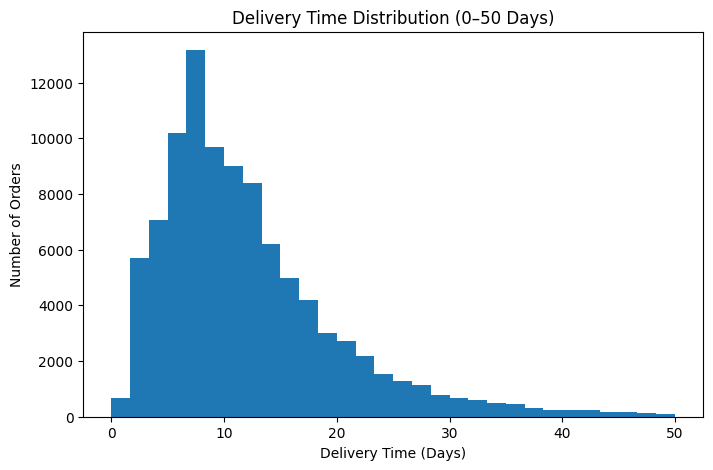

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    completed["delivery_days"].dropna(),
    bins=30,
    range=(0, 50)
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.title("Delivery Time Distribution (0–50 Days)")

plt.show()


In [20]:
print("Minimum Delivery Time:", completed["delivery_days"].min())
print("Median Delivery Time:", completed["delivery_days"].median())
print("Maximum Delivery Time:", completed["delivery_days"].max())

Minimum Delivery Time: 0.5334143518518518
Median Delivery Time: 10.21775462962963
Maximum Delivery Time: 209.6286111111111
